# 06 · Trained layer-adapter heads

**Why:** in notebook 04, every audio view is a *pooled* clip vector (mean and std over time) fed to a linear or kernel model. The Speak & Improve 2025 winner (Cai et al., "perezoso") instead trained a small head **on top of the frozen layers**: one adapter per layer, then temporal mean+std pooling. That was their best single grader.

**What changes here vs. notebook 04:**

| | Notebook 04 heads | Adapter heads |
|---|---|---|
| Input | pooled clip vector | sequence of 1-s segment states, 4 layers |
| Layers | averaged | each layer gets its own adapter (learned weighting) |
| Duration shift | crops only as extra rows | **every step sees a random 38–52 s window** (test ≈ 45 s) |
| Loss | squared error | squared error + λ·(1 − Pearson): both halves of the metric |
| Capacity | closed form | ~0.6M parameters with dropout, weight decay, early stopping on held-out *speakers* |

Evaluation is identical to the other heads: 5 speaker-grouped folds × 5 seeds, plus the test-like short-clip OOF on the same 40–50 s crops.

In [1]:
import os, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
for p in Path("/kaggle/input").glob("*/src"):
    sys.path.insert(0, str(p))
from shl import adapter, metrics, population

OUT = Path("/kaggle/working") if Path("/kaggle/working").exists() else ROOT / "artifacts"
FEAT, PRED = OUT / "features", OUT / "preds"
meta = pd.read_csv(OUT / "meta.csv")
fold_df = pd.read_csv(OUT / "folds_joint.csv"); folds = fold_df.drop(columns="uid")   # speaker + prompt held out
row_of = {u: i for i, u in enumerate(meta.uid)}
fit_rows = np.array([row_of[u] for u in fold_df.uid])
test_rows = np.where(meta.split == "test")[0]
y = meta.label.values[fit_rows]; groups = meta.group.values[fit_rows]
w = None   # population weights hurt on the leaderboard (run 3): plain sampling

crops = pd.read_csv(FEAT / "crops.csv")
pos_in_fit = {u: i for i, u in enumerate(fold_df.uid)}
keep = crops.uid.isin(pos_in_fit).values
crop_src = np.array([pos_in_fit[u] for u in crops.uid[keep]])
# crop windows in whole seconds (segments are 1 s); same windows as notebook 04
crop_win = np.stack([np.floor(crops.start_s[keep]).astype(int), np.round(crops.len_s[keep]).astype(int)], 1)
print(len(y), "fit clips |", len(crop_src), "crops | device:", "cuda" if torch.cuda.is_available() else "cpu")

732 fit clips | 1464 crops | device: cuda


In [2]:
cfg = adapter.AdapterConfig(model_seeds=2)   # 2 models per fold: single models are noisy, bagging helped
print(cfg)
results = {}
ENCODERS = ["whisper_v3", "wavlm_large", "hubert_large"]   # w2v-BERT adapter: smallest gain (-0.005), dropped
print("adapter heads for:", ENCODERS)
for key in ENCODERS:
    S_all = np.load(FEAT / f"seg_{key}.npy", mmap_mode="r")
    lens_all = np.load(FEAT / f"seg_{key}_lens.npy")
    S, lens = np.asarray(S_all[fit_rows]), lens_all[fit_rows]
    S_te, lens_te = np.asarray(S_all[test_rows]), lens_all[test_rows]
    print(f"{key}: segments {S.shape}")
    t0 = time.time()
    name = f"{key}_adapter"
    cache = PRED / f"{name}__mlp.npz"
    if cache.exists() and not os.environ.get("RETRAIN"):     # set RETRAIN=1 to train again (~10 min per encoder on GPU)
        r = dict(np.load(cache))
    else:
        r = adapter.run_adapter_cv(S, lens, y, groups, folds, S_te, lens_te, crop_src, crop_win, cfg, w=w)
        np.savez(cache, **r)
    results[name] = r
    print(f"{name}: full {metrics.composite(y, r['oof']):.4f} | short {metrics.composite(y, r['oof_short']):.4f} "
          f"| {time.time() - t0:.0f}s")
    del S, S_te

AdapterConfig(hidden=128, dropout=0.2, lr=0.001, weight_decay=0.05, epochs=60, batch=32, pearson_weight=0.5, win_min_s=38, win_max_s=52, eval_win_s=45, patience=12, model_seeds=2)
adapter heads for: ['whisper_v3', 'wavlm_large', 'hubert_large']


whisper_v3: segments (732, 4, 62, 1280)
whisper_v3_adapter: full 0.4035 | short 0.4059 | 0s


wavlm_large: segments (732, 4, 62, 1024)
wavlm_large_adapter: full 0.4178 | short 0.4211 | 0s


hubert_large: segments (732, 4, 62, 1024)
hubert_large_adapter: full 0.4424 | short 0.4431 | 0s


## Comparison with the pooled heads of notebook 04
Same speaker+prompt folds, same crops, true leaderboard metric on the test-like short score. Δ < 0 means the adapter is better.

,view,pooled ridge (short),adapter (short),delta,adapter rmse (short),adapter r (short)
0,whisper_v3,0.4268,0.4059,-0.0208,0.5647,0.8322
1,wavlm_large,0.4297,0.4211,-0.0087,0.5821,0.8205
2,hubert_large,0.4557,0.4431,-0.0126,0.6066,0.8021


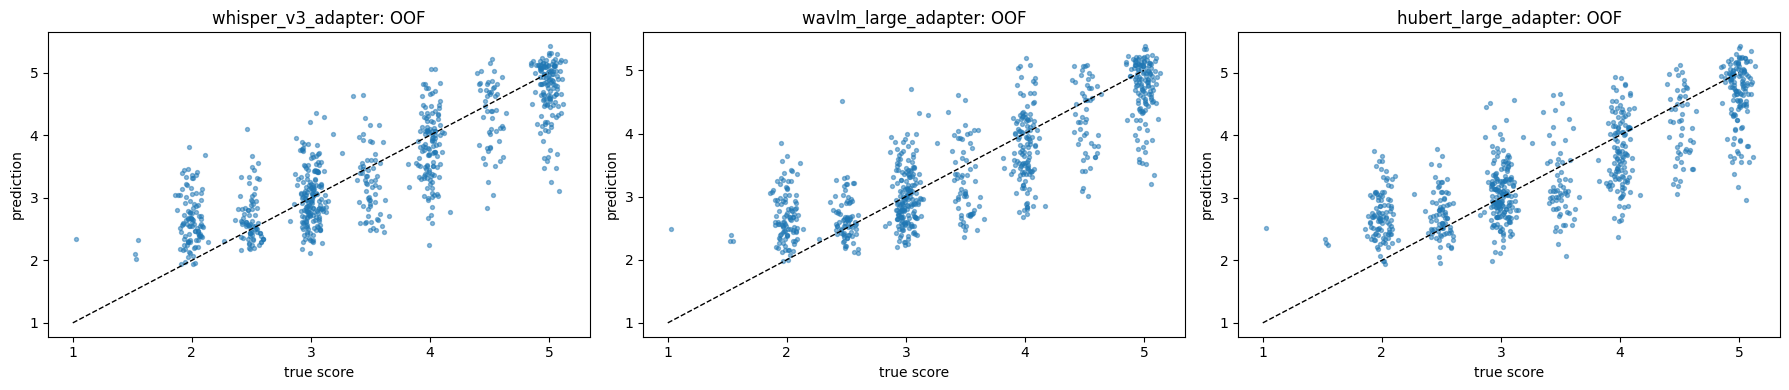

In [3]:
rows = []
for name, r in results.items():
    key = name.replace("_adapter", "")
    ref_path = next(p for p in (PRED / f"{key}_A__ridge.npz", PRED / f"{key}_B__ridge.npz") if p.exists())
    ref = np.load(ref_path)                      # the pooled band ridge kept in notebook 04
    rows.append({"view": key, "pooled ridge (short)": metrics.composite(y, ref["oof_short"]),
                 "adapter (short)": metrics.composite(y, r["oof_short"]),
                 "delta": metrics.composite(y, r["oof_short"]) - metrics.composite(y, ref["oof_short"]),
                 "adapter rmse (short)": metrics.rmse(y, r["oof_short"]), "adapter r (short)": metrics.pearson(y, r["oof_short"])})
cmp = pd.DataFrame(rows); display(cmp.round(4))
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 4))
for ax, (name, r) in zip(np.atleast_1d(axes), results.items()):
    ax.scatter(y + np.random.default_rng(0).normal(0, .06, len(y)), r["oof_short"], s=8, alpha=.5)
    ax.plot([1, 5], [1, 5], "k--", lw=1)
    ax.set(title=f"{name}: OOF", xlabel="true score", ylabel="prediction")
plt.tight_layout(); plt.show()